# 학생 성취도 예측 프로젝트 — EDA

**데이터**: `hybrid_student_performance_1200.csv` (1,200행 × 36열)  
**분석 목표**  
- 타겟 ① `cgpa_category` — CGPA 구간 예측 (회귀 대용 분류)  
- 타겟 ② `performance_risk_level` — 위험도 분류 (Low / Moderate / High Risk)  
- 핵심 질문: 공부 시간·출석률·스트레스·수면 등 행동 변수가 성적에 얼마나 영향을 미치는가?  

**학번**: 20242530 정명진

---
## 0. 환경 설정

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# 한글 폰트 (Windows)
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('라이브러리 로드 완료')

라이브러리 로드 완료


---
## 1. 데이터 로드 및 기본 정보

In [2]:
# 노트북(report/) 기준 archive/ 경로
DATA_PATH = os.path.join(os.path.dirname(os.path.abspath('__file__')),
                         'archive', 'hybrid_student_performance_1200.csv')

df = pd.read_csv(DATA_PATH)
print(f'데이터 형태: {df.shape[0]}행 × {df.shape[1]}열')
df.head(3)

데이터 형태: 1200행 × 36열


,student_id,timestamp,year_class,program_stream,age,gender,cgpa_category,academic_satisfaction,study_hours_daily,daily_productivity,...,projects_internships,programming_foundation,events_participation,assignments_on_time,attendance_percentage,strongest_asset,internal_barrier,external_resources,external_pressure,performance_risk_level
0,STU0001,3/29/2026 20:54:43,Second Year (SY),BCA,20,Female,8.5 – 9.4,Neutral,Less than 1 hour,2.0,...,"Yes, actively working on projects/internship","Basic knowledge, learning while practicing",Occasionally participate in events,Often,Above 85%,"Technical/Hard Skills (Coding, Math, Logic)",Lack of Consistency or Determination (Difficul...,Occasionally (When needed),No Impact (Fully supportive environment),Moderate Risk
1,STU0002,3/29/2026 21:20:15,Second Year (SY),BCA,20,Male,8.5 – 9.4,Unsatisfied,1–2 hours,1.0,...,"Yes, actively working on projects/internship","Limited knowledge, theoretical only","Rarely participate, mostly observe",Often,76% – 85%,"Creative/Design Skills (Innovation, UI/UX, Con...",Lack of Consistency or Determination (Difficul...,Occasionally (When needed),Moderate Impact (Occasional disruption),Moderate Risk
2,STU0003,3/29/2026 21:21:35,Second Year (SY),BCA,19,Male,5.0 – 6.9,Neutral,1–2 hours,2.0,...,"Yes, actively working on projects/internship","Basic knowledge, learning while practicing","Rarely participate, mostly observe",Often,Less than 50%,"Technical/Hard Skills (Coding, Math, Logic)",Difficulty with Focus / Concentration,Rarely (Passive),High Impact (Frequent disruption),High Risk


In [3]:
# 컬럼별 타입 · 결측치 · 유니크 값 수
info = pd.DataFrame({
    '타입'      : df.dtypes,
    '결측치'    : df.isnull().sum(),
    '결측률(%)'  : (df.isnull().sum() / len(df) * 100).round(2),
    '유니크 수' : df.nunique()
})
display(info)

,타입,결측치,결측률(%),유니크 수
student_id,object,0,0.00,1200
timestamp,object,0,0.00,1171
year_class,object,0,0.00,6
program_stream,object,0,0.00,7
age,int64,0,0.00,10
gender,object,0,0.00,3
cgpa_category,object,0,0.00,4
academic_satisfaction,object,0,0.00,5
study_hours_daily,object,0,0.00,3
daily_productivity,float64,34,2.83,5


In [4]:
# 수치형 기술통계
numeric_cols = df.select_dtypes(include='number').columns.tolist()
print('수치형 컬럼:', numeric_cols)
df[numeric_cols].describe().T.style.background_gradient(cmap='Blues', subset=['mean','std'])

수치형 컬럼: ['age', 'daily_productivity', 'energy_level', 'stress_level', 'routine_rating']


,count,mean,std,min,25%,50%,75%,max
age,1200.000000,20.807500,2.186953,17.000000,19.000000,21.000000,22.000000,26.000000
daily_productivity,1166.000000,2.686964,1.178761,1.000000,2.000000,3.000000,3.000000,5.000000
energy_level,1172.000000,3.227816,1.145359,1.000000,2.000000,3.000000,4.000000,5.000000
stress_level,1165.000000,3.151931,1.189194,1.000000,2.000000,3.000000,4.000000,5.000000
routine_rating,1159.000000,2.105263,0.788057,1.000000,1.000000,2.000000,3.000000,3.000000


In [5]:
# 중복행 / 타겟 분포 확인
print(f'중복 행: {df.duplicated().sum()}개')
print('\n[타겟 ①] cgpa_category')
print(df['cgpa_category'].value_counts())
print('\n[타겟 ②] performance_risk_level')
print(df['performance_risk_level'].value_counts())

중복 행: 0개

[타겟 ①] cgpa_category
cgpa_category
7.0 – 8.4     420
8.5 – 9.4     362
5.0 – 6.9     236
9.5 – 10.0    182
Name: count, dtype: int64

[타겟 ②] performance_risk_level
performance_risk_level
Moderate Risk    572
High Risk        452
Low Risk         176
Name: count, dtype: int64


---
## 2. 타겟 변수 분포

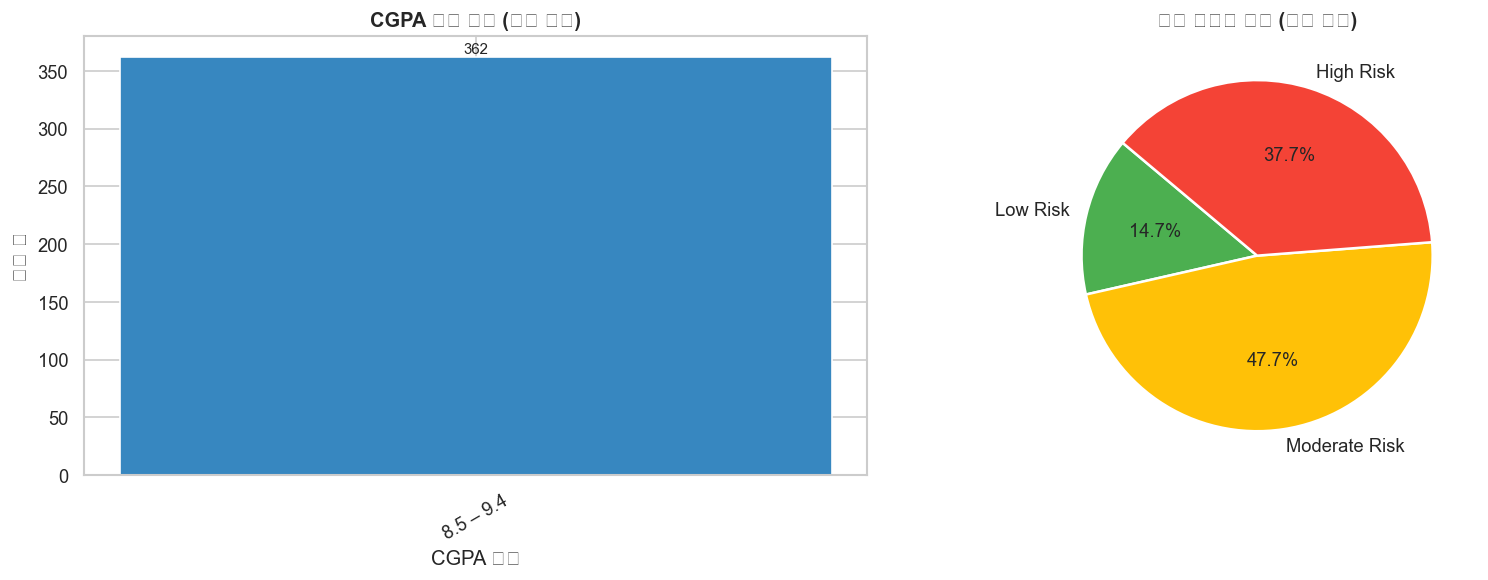

In [6]:
# 순서 정의 (공통 사용)
CGPA_ORDER  = ['Below 6.0', '6.0 – 6.9', '7.0 – 7.9', '7.9 – 8.4', '8.5 – 9.4', '9.5 and above']
RISK_ORDER  = ['Low Risk', 'Moderate Risk', 'High Risk']
STUDY_ORDER = ['Less than 1 hour', '1–2 hours', '2–3 hours', '3–4 hours', '4–5 hours', 'More than 5 hours']
SLEEP_ORDER = ['Less than 5 hours', '5–6 hours', '6–7 hours', '7–8 hours', 'More than 8 hours']
ATT_ORDER   = ['Below 60%', '60% – 75%', '76% – 85%', 'Above 85%']

cgpa_order = [c for c in CGPA_ORDER if c in df['cgpa_category'].unique()]
risk_order = [r for r in RISK_ORDER if r in df['performance_risk_level'].unique()]

RISK_COLOR  = {'Low Risk': '#4CAF50', 'Moderate Risk': '#FFC107', 'High Risk': '#F44336'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ① CGPA 구간 막대
cgpa_cnt = df['cgpa_category'].value_counts().reindex(cgpa_order, fill_value=0)
bars = axes[0].bar(cgpa_cnt.index, cgpa_cnt.values,
                   color=sns.color_palette('Blues_d', len(cgpa_cnt)), edgecolor='white')
for b in bars:
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 3,
                 int(b.get_height()), ha='center', fontsize=9)
axes[0].set_title('CGPA 구간 분포 (회귀 타겟)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('CGPA 구간')
axes[0].set_ylabel('학생 수')
axes[0].tick_params(axis='x', rotation=30)

# ② 위험도 파이
risk_cnt = df['performance_risk_level'].value_counts().reindex(risk_order, fill_value=0)
axes[1].pie(risk_cnt.values, labels=risk_cnt.index, autopct='%1.1f%%',
            colors=[RISK_COLOR[r] for r in risk_order], startangle=140,
            textprops={'fontsize': 11}, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('성과 위험도 분포 (분류 타겟)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 3. 수치형 변수 분포

TypeError: Could not convert string 'NeutralUnsatisfiedNeutralSatisfiedNeutralNeutralNeutralSatisfiedNeutralVery satisfiedNeutralVery satisfiedNeutralUnsatisfiedSatisfiedNeutralVery satisfiedUnsatisfiedUnsatisfiedSatisfiedNeutralSatisfiedNeutralVery satisfiedVery satisfiedSatisfiedUnsatisfiedUnsatisfiedUnsatisfiedVery satisfiedNeutralVery satisfiedNeutralNeutralNeutralUnsatisfiedVery satisfiedNeutralVery satisfiedNeutralUnsatisfiedSatisfiedNeutralUnsatisfiedSatisfiedSatisfiedNeutralNeutralNeutralVery unsatisfiedVery satisfiedUnsatisfiedSatisfiedSatisfiedVery unsatisfiedUnsatisfiedVery unsatisfiedNeutralVery satisfiedNeutralVery satisfiedNeutralUnsatisfiedNeutralSatisfiedVery unsatisfiedVery unsatisfiedSatisfiedNeutralUnsatisfiedSatisfiedNeutralNeutralNeutralSatisfiedNeutralSatisfiedSatisfiedNeutralNeutralSatisfiedVery unsatisfiedVery satisfiedVery satisfiedSatisfiedNeutralSatisfiedVery satisfiedSatisfiedUnsatisfiedVery satisfiedNeutralUnsatisfiedVery satisfiedUnsatisfiedSatisfiedVery s

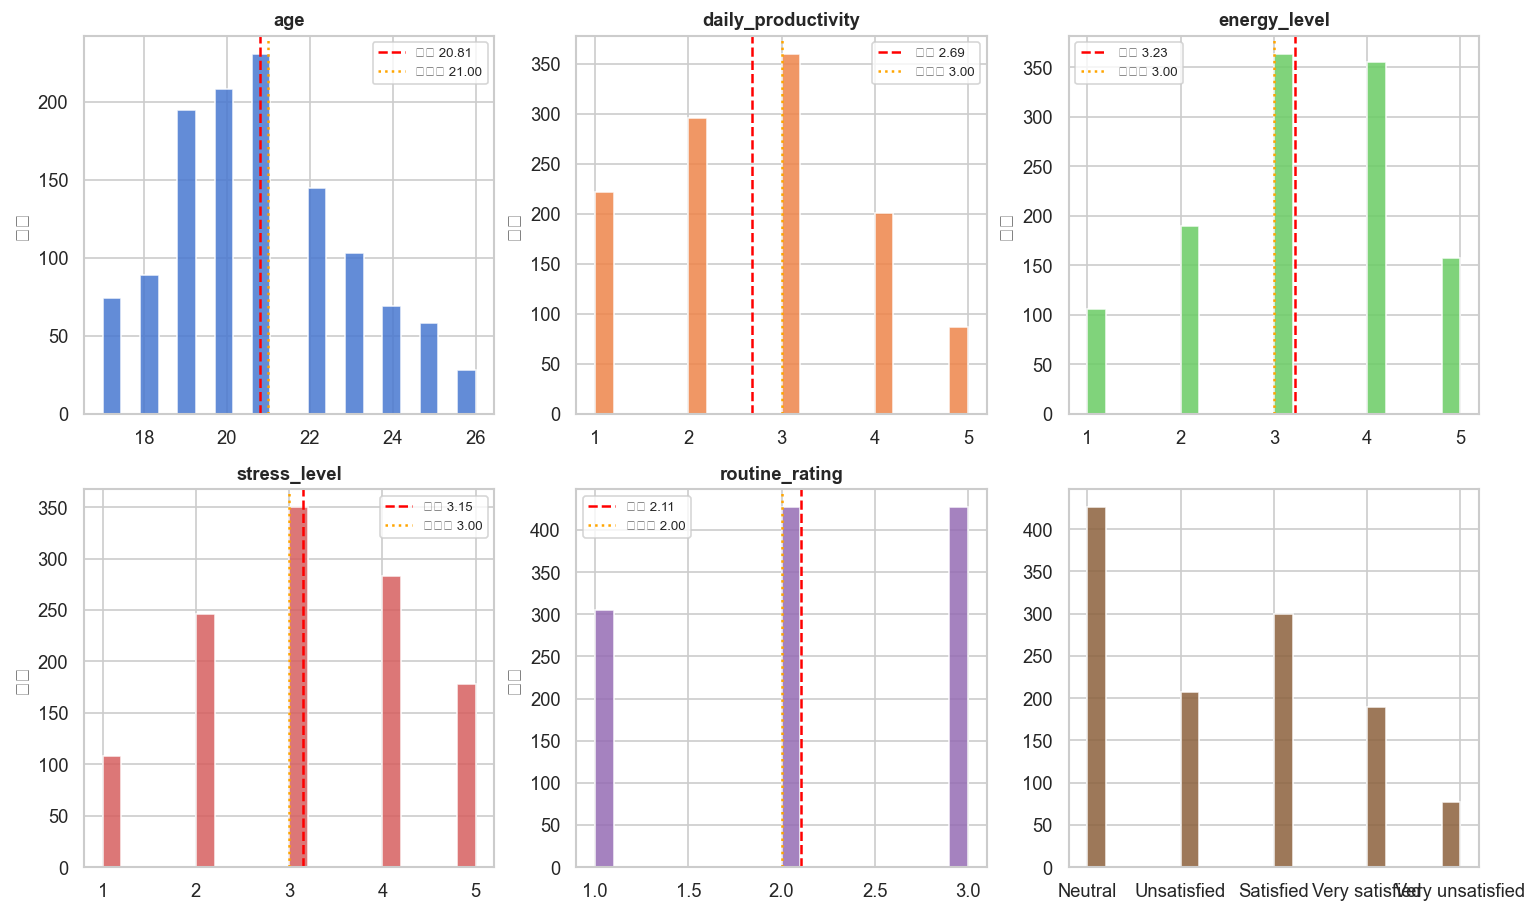

In [7]:
NUM_FEATS = ['age', 'daily_productivity', 'energy_level',
             'stress_level', 'routine_rating', 'academic_satisfaction']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
palette = sns.color_palette('muted', len(NUM_FEATS))

for i, col in enumerate(NUM_FEATS):
    data = df[col].dropna()
    axes[i].hist(data, bins=20, color=palette[i], edgecolor='white', alpha=0.85)
    axes[i].axvline(data.mean(),   color='red',    linestyle='--', lw=1.5, label=f'평균 {data.mean():.2f}')
    axes[i].axvline(data.median(), color='orange', linestyle=':',  lw=1.5, label=f'중앙값 {data.median():.2f}')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('빈도')
    axes[i].legend(fontsize=8)

plt.suptitle('수치형 변수 히스토그램', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# 위험도별 수치형 변수 박스플롯
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(NUM_FEATS):
    sns.boxplot(data=df, x='performance_risk_level', y=col,
                order=risk_order, palette=RISK_COLOR,
                ax=axes[i], width=0.5, flierprops={'marker': 'o', 'markersize': 3})
    axes[i].set_title(f'{col} by 위험도', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('위험도별 수치형 변수 (박스플롯)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 4. 범주형 변수 분포

In [ ]:
cat_plots = [
    ('gender',                None,        '성별'),
    ('year_class',            None,        '학년'),
    ('program_stream',        None,        '전공 트랙'),
    ('study_hours_daily',     STUDY_ORDER, '일일 공부 시간'),
    ('sleep_hours',           SLEEP_ORDER, '수면 시간'),
    ('attendance_percentage', ATT_ORDER,   '출석률'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
pal = sns.color_palette('pastel', 8)

for i, (col, order, title) in enumerate(cat_plots):
    if order:
        idx = [o for o in order if o in df[col].unique()]
        counts = df[col].value_counts().reindex(idx, fill_value=0)
    else:
        counts = df[col].value_counts()
    bars = axes[i].barh(counts.index[::-1], counts.values[::-1],
                         color=pal[:len(counts)], edgecolor='white')
    for b in bars:
        axes[i].text(b.get_width() + 1, b.get_y() + b.get_height()/2,
                     int(b.get_width()), va='center', fontsize=8)
    axes[i].set_title(title, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('학생 수')
    axes[i].set_xlim(0, counts.max() * 1.14)

plt.suptitle('주요 범주형 변수 분포', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

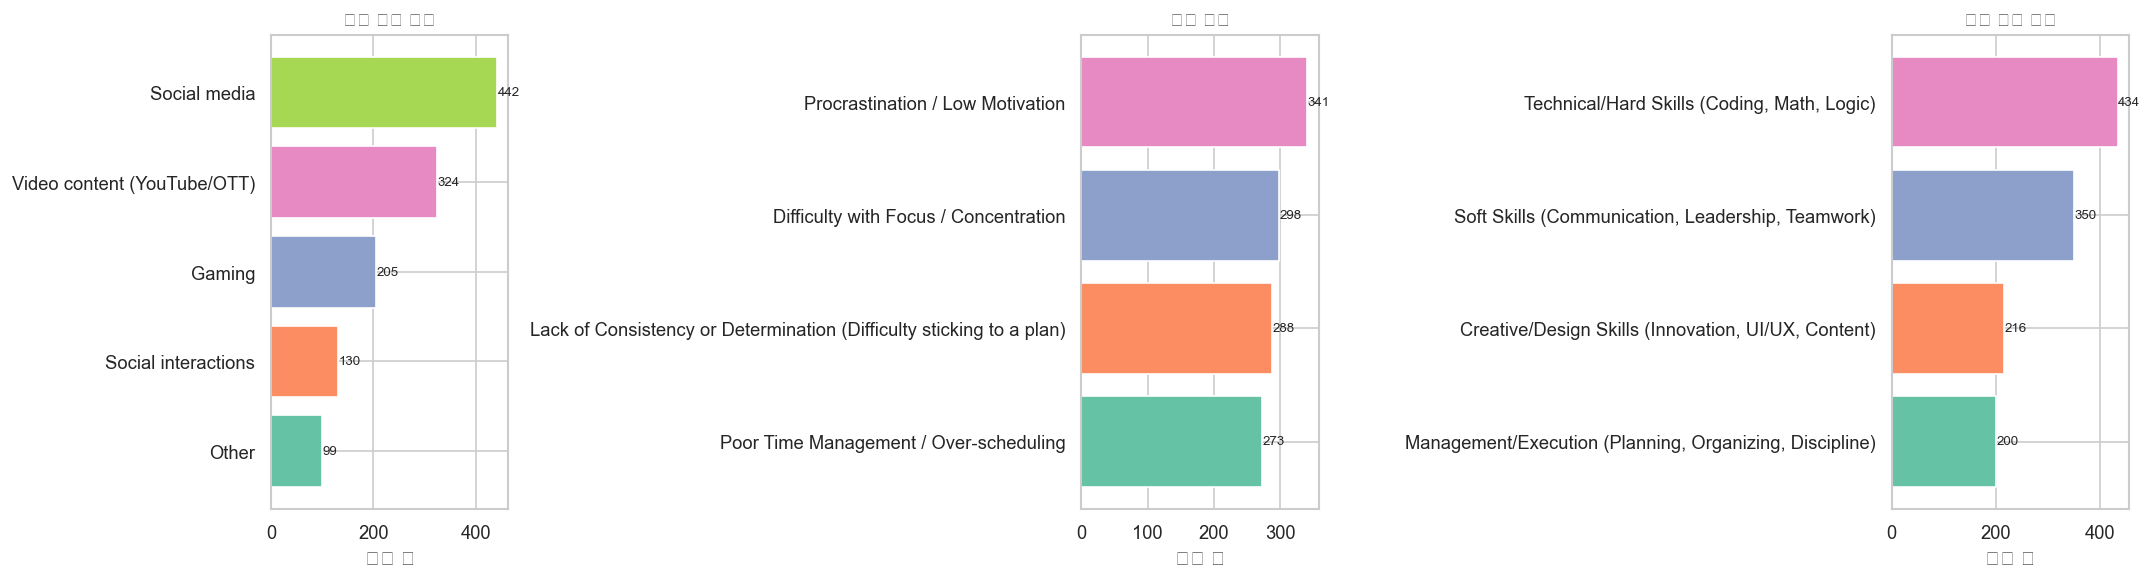

In [8]:
# 방해 요소 / 내부 장벽 / 강점 분포
bar_plots = [
    ('main_distractor', '주요 방해 요소'),
    ('internal_barrier', '내부 장벽'),
    ('strongest_asset', '가장 강한 역량'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (col, title) in zip(axes, bar_plots):
    counts = df[col].value_counts()
    bars = ax.barh(counts.index[::-1], counts.values[::-1],
                   color=sns.color_palette('Set2', len(counts)), edgecolor='white')
    for b in bars:
        ax.text(b.get_width() + 1, b.get_y() + b.get_height()/2,
                int(b.get_width()), va='center', fontsize=8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('학생 수')

plt.tight_layout()
plt.show()

---
## 5. 수치형 변수 상관관계 히트맵

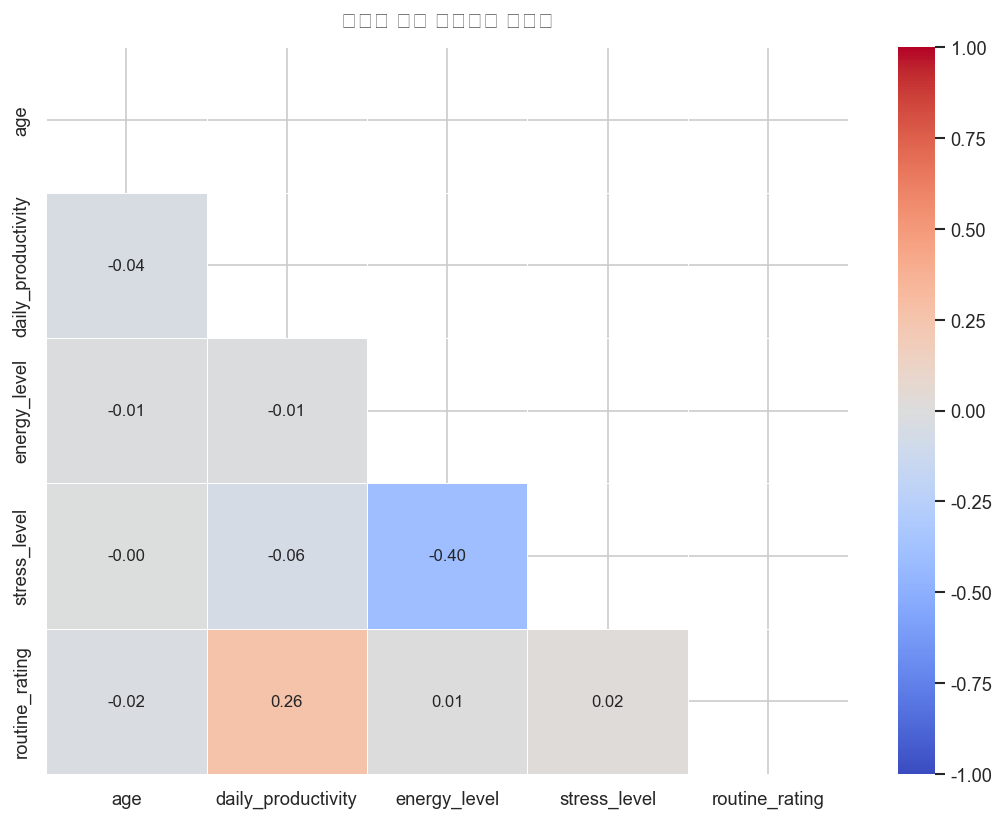


▶ 상관계수 절댓값 상위 5쌍
               변수1                변수2      상관계수
      stress_level       energy_level -0.404968
    routine_rating daily_productivity  0.261866
      stress_level daily_productivity -0.057631
daily_productivity                age -0.039829
    routine_rating                age -0.024808


In [9]:
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 10}, ax=ax)
ax.set_title('수치형 변수 상관관계 히트맵', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# 상관계수 절댓값 TOP 5 쌍 출력
corr_pairs = (corr.where(~mask)
                  .stack()
                  .reset_index()
                  .rename(columns={'level_0':'변수1','level_1':'변수2', 0:'상관계수'}))
print('\n▶ 상관계수 절댓값 상위 5쌍')
print(corr_pairs.assign(abs_r=corr_pairs['상관계수'].abs())
                .sort_values('abs_r', ascending=False)
                .drop('abs_r', axis=1)
                .head(5).to_string(index=False))

---
## 6. 주요 변수 × 타겟 관계 분석 (심화)

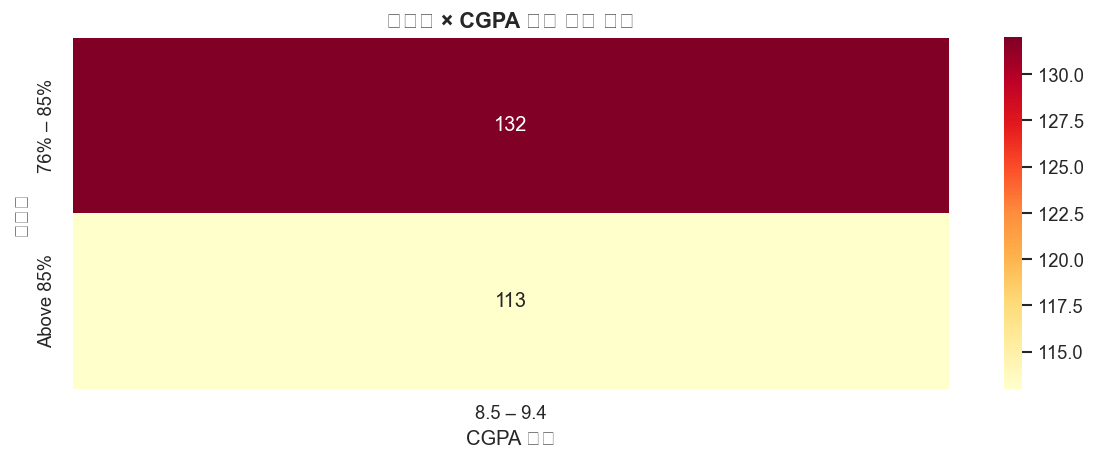

In [10]:
# 6-1. 출석률 × CGPA 구간 교차표 히트맵
att_order = [a for a in ATT_ORDER if a in df['attendance_percentage'].unique()]
cross_att = (pd.crosstab(df['attendance_percentage'], df['cgpa_category'])
               .reindex(att_order, fill_value=0)
               .reindex(columns=cgpa_order, fill_value=0))

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(cross_att, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('출석률 × CGPA 구간 교차 빈도', fontsize=13, fontweight='bold')
ax.set_xlabel('CGPA 구간')
ax.set_ylabel('출석률')
plt.tight_layout()
plt.show()

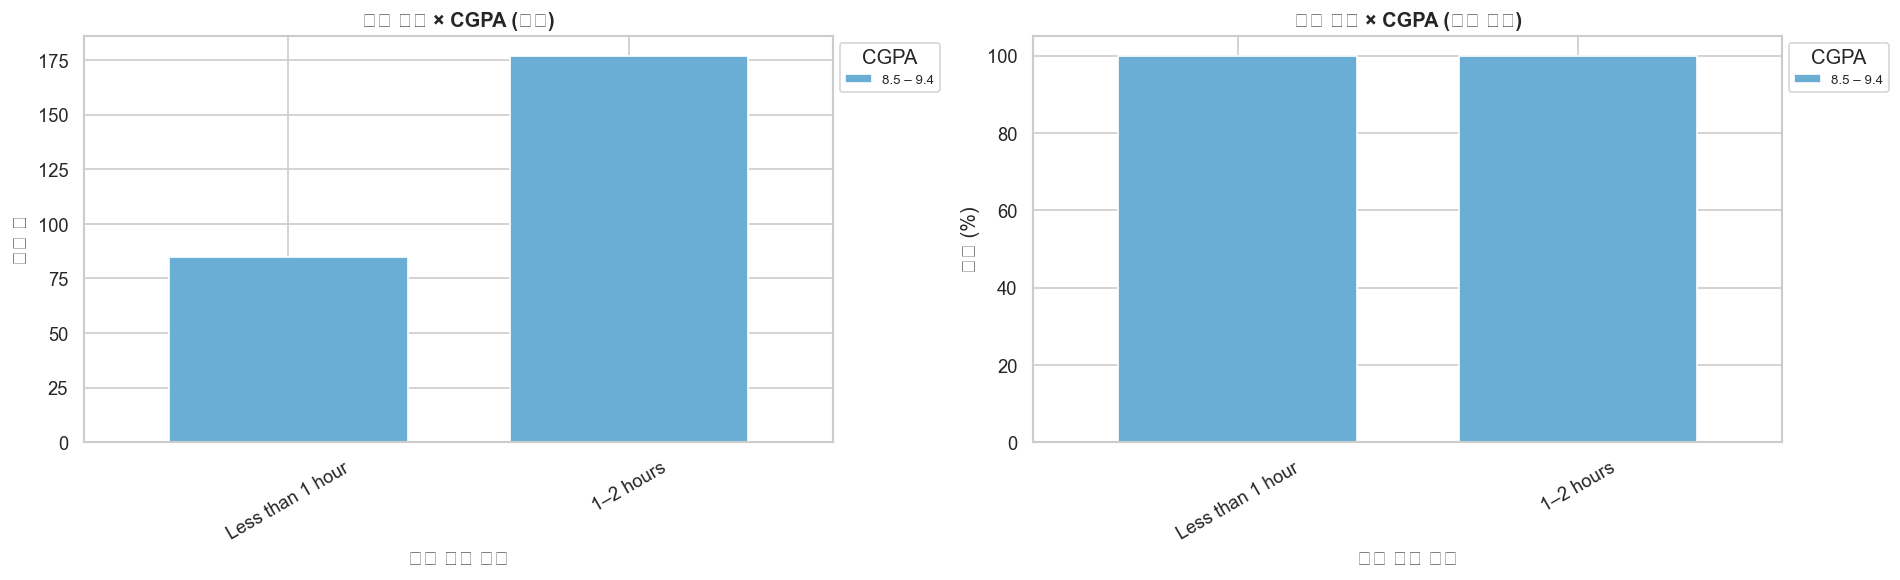

In [11]:
# 6-2. 일일 공부 시간 × CGPA 구간 — 누적 비율 막대
study_order = [s for s in STUDY_ORDER if s in df['study_hours_daily'].unique()]
cross_study = (pd.crosstab(df['study_hours_daily'], df['cgpa_category'])
                 .reindex(study_order, fill_value=0)
                 .reindex(columns=cgpa_order, fill_value=0))
cross_study_pct = cross_study.div(cross_study.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 절대 빈도
cross_study.plot(kind='bar', color=sns.color_palette('Blues', len(cgpa_order)),
                 ax=axes[0], edgecolor='white', width=0.7)
axes[0].set_title('공부 시간 × CGPA (빈도)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('일일 공부 시간')
axes[0].set_ylabel('학생 수')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='CGPA', fontsize=8, bbox_to_anchor=(1, 1))

# 비율 누적
cross_study_pct.plot(kind='bar', stacked=True,
                      color=sns.color_palette('Blues', len(cgpa_order)),
                      ax=axes[1], edgecolor='white', width=0.7)
axes[1].set_title('공부 시간 × CGPA (누적 비율)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('일일 공부 시간')
axes[1].set_ylabel('비율 (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='CGPA', fontsize=8, bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

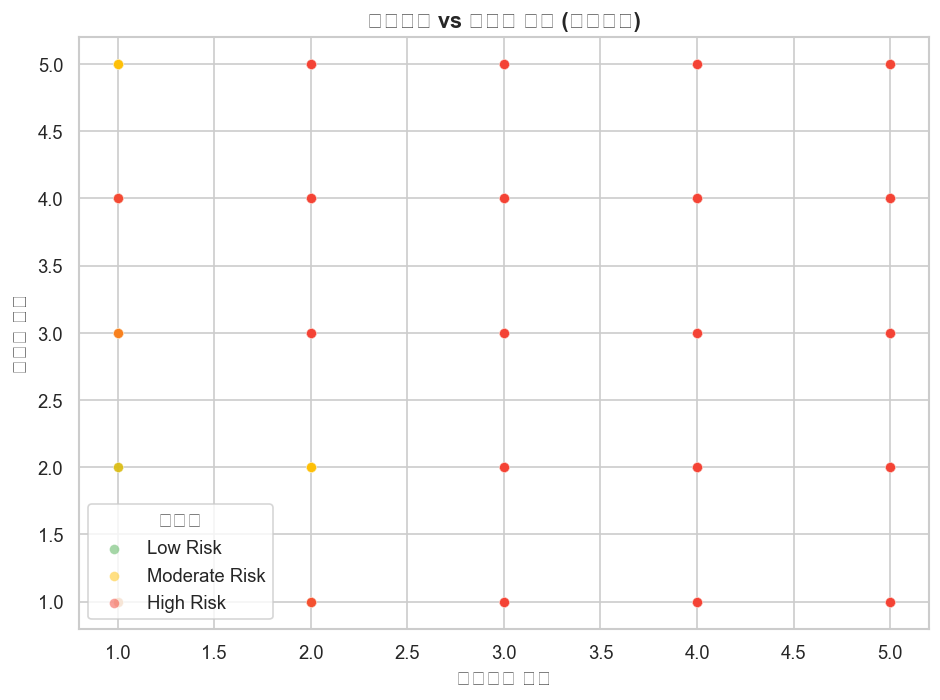

In [12]:
# 6-3. 스트레스 × 에너지 산점도 (위험도 색상 + 밀도 경계선)
fig, ax = plt.subplots(figsize=(8, 6))

for risk in risk_order:
    g = df[df['performance_risk_level'] == risk]
    ax.scatter(g['stress_level'], g['energy_level'],
               c=RISK_COLOR[risk], label=risk, alpha=0.5, s=35,
               edgecolors='white', linewidths=0.3)

ax.set_title('스트레스 vs 에너지 레벨 (위험도별)', fontsize=13, fontweight='bold')
ax.set_xlabel('스트레스 레벨')
ax.set_ylabel('에너지 레벨')
ax.legend(title='위험도')
plt.tight_layout()
plt.show()

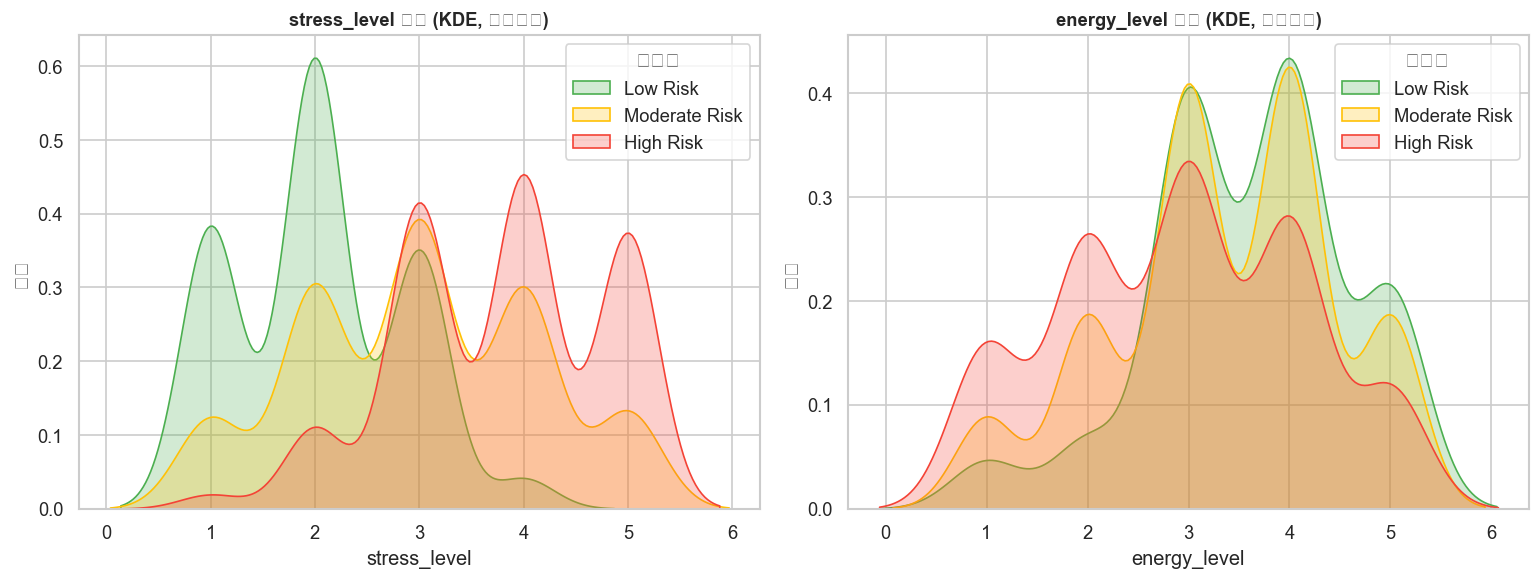

In [13]:
# 6-4. 위험도별 KDE (스트레스 / 에너지)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for col, ax in zip(['stress_level', 'energy_level'], axes):
    for risk in risk_order:
        g = df[df['performance_risk_level'] == risk][col].dropna()
        sns.kdeplot(g, ax=ax, label=risk, color=RISK_COLOR[risk], fill=True, alpha=0.25)
    ax.set_title(f'{col} 분포 (KDE, 위험도별)', fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('밀도')
    ax.legend(title='위험도')

plt.tight_layout()
plt.show()

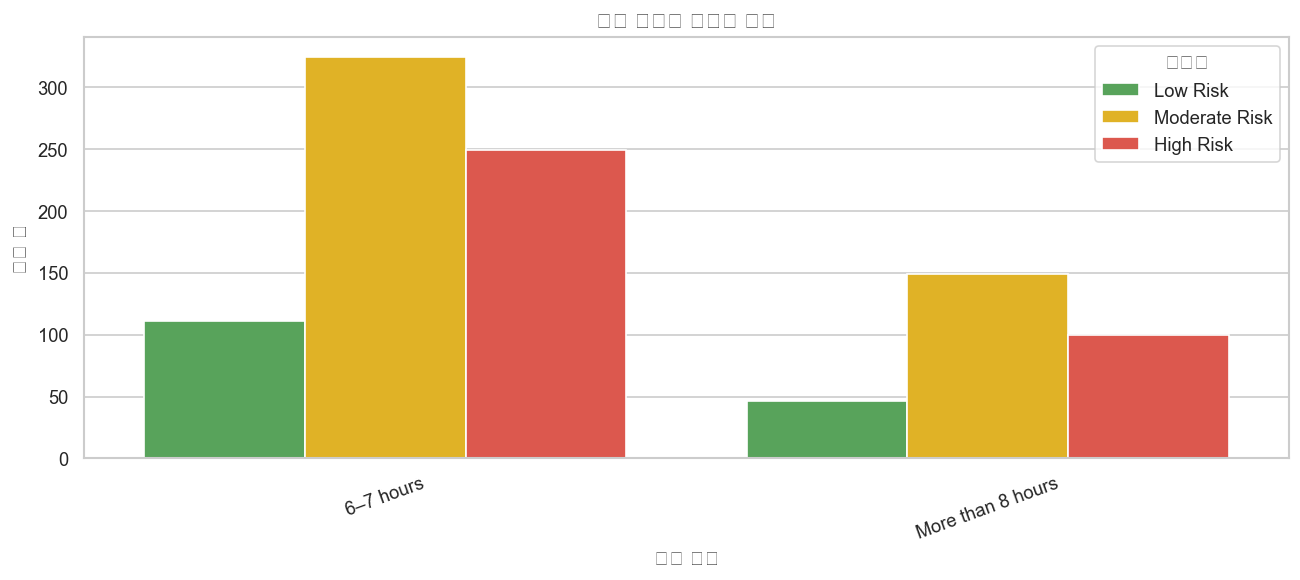

In [14]:
# 6-5. 수면 시간 × 위험도 카운트플롯
sleep_order = [s for s in SLEEP_ORDER if s in df['sleep_hours'].unique()]

fig, ax = plt.subplots(figsize=(11, 5))
sns.countplot(data=df, x='sleep_hours', hue='performance_risk_level',
              order=sleep_order, hue_order=risk_order,
              palette=RISK_COLOR, ax=ax, edgecolor='white')
ax.set_title('수면 시간별 위험도 분포', fontsize=13, fontweight='bold')
ax.set_xlabel('수면 시간')
ax.set_ylabel('학생 수')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='위험도')
plt.tight_layout()
plt.show()

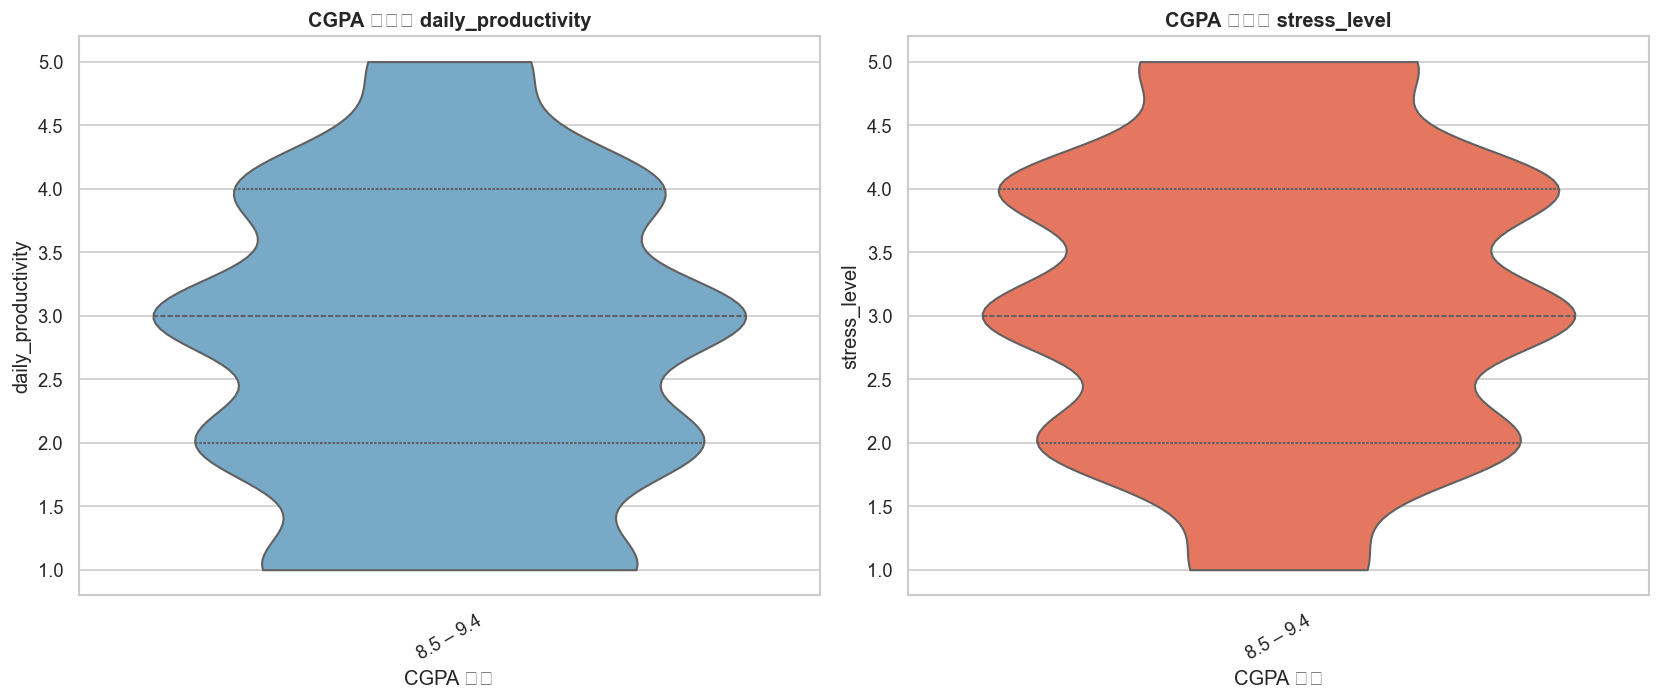

In [15]:
# 6-6. CGPA별 생산성 / 스트레스 바이올린 플롯
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, col, pal in zip(axes,
                         ['daily_productivity', 'stress_level'],
                         ['Blues', 'Reds']):
    sns.violinplot(data=df, x='cgpa_category', y=col,
                   order=cgpa_order, palette=pal, ax=ax, cut=0, inner='quartile')
    ax.set_title(f'CGPA 구간별 {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('CGPA 구간')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

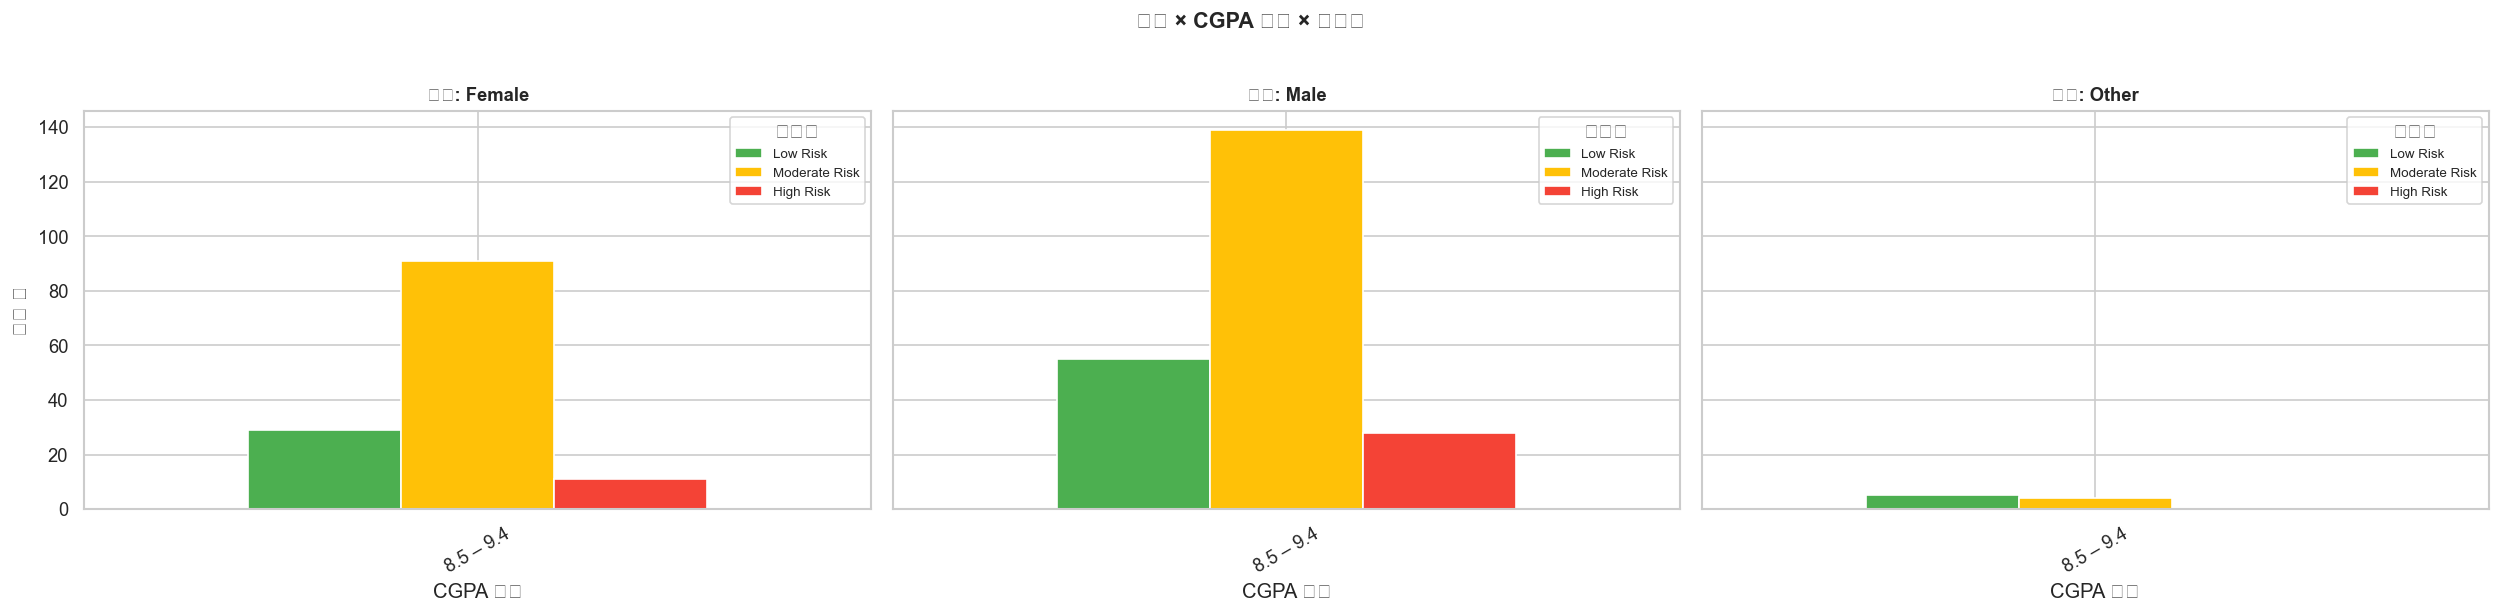

In [16]:
# 6-7. 성별 × CGPA × 위험도 (Facet 막대)
genders = sorted(df['gender'].dropna().unique())
fig, axes = plt.subplots(1, len(genders), figsize=(7 * len(genders), 5), sharey=True)
if len(genders) == 1:
    axes = [axes]

for ax, gender in zip(axes, genders):
    sub = df[df['gender'] == gender]
    cnt = sub.groupby(['cgpa_category', 'performance_risk_level']).size().unstack(fill_value=0)
    cnt = cnt.reindex(cgpa_order, fill_value=0)
    for r in risk_order:
        if r not in cnt.columns:
            cnt[r] = 0
    cnt[risk_order].plot(kind='bar', ax=ax,
                          color=[RISK_COLOR[r] for r in risk_order],
                          edgecolor='white', width=0.7)
    ax.set_title(f'성별: {gender}', fontsize=11, fontweight='bold')
    ax.set_xlabel('CGPA 구간')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='위험도', fontsize=8)

axes[0].set_ylabel('학생 수')
plt.suptitle('성별 × CGPA 구간 × 위험도', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

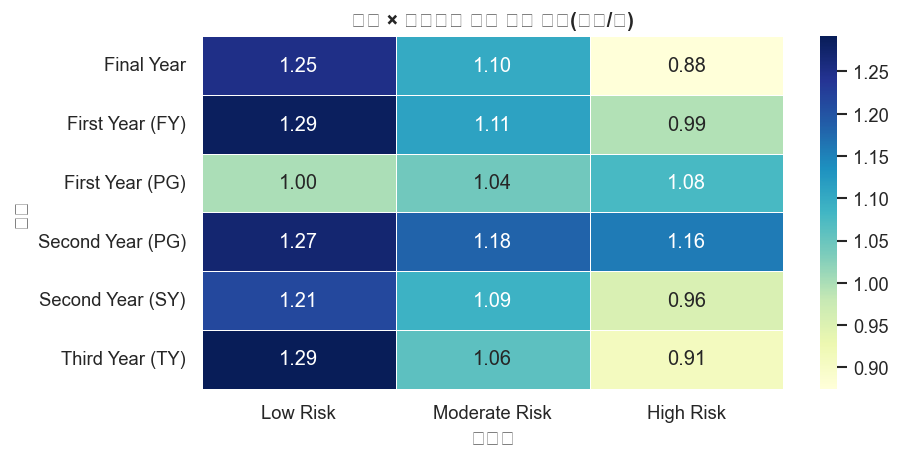

In [17]:
# 6-8. 학년 × 위험도 × 공부 시간 — 그룹 평균 히트맵
# study_hours_daily를 숫자로 변환
study_num_map = {
    'Less than 1 hour': 0.5,
    '1–2 hours': 1.5, '1-2 hours': 1.5,
    '2–3 hours': 2.5, '2-3 hours': 2.5,
    '3–4 hours': 3.5, '3-4 hours': 3.5,
    '4–5 hours': 4.5, '4-5 hours': 4.5,
    'More than 5 hours': 6.0
}
df['study_hours_num'] = df['study_hours_daily'].map(study_num_map)

pivot = df.pivot_table(values='study_hours_num',
                        index='year_class',
                        columns='performance_risk_level',
                        aggfunc='mean')[risk_order]

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu', linewidths=0.5, ax=ax)
ax.set_title('학년 × 위험도별 평균 공부 시간(시간/일)', fontsize=12, fontweight='bold')
ax.set_xlabel('위험도')
ax.set_ylabel('학년')
plt.tight_layout()
plt.show()

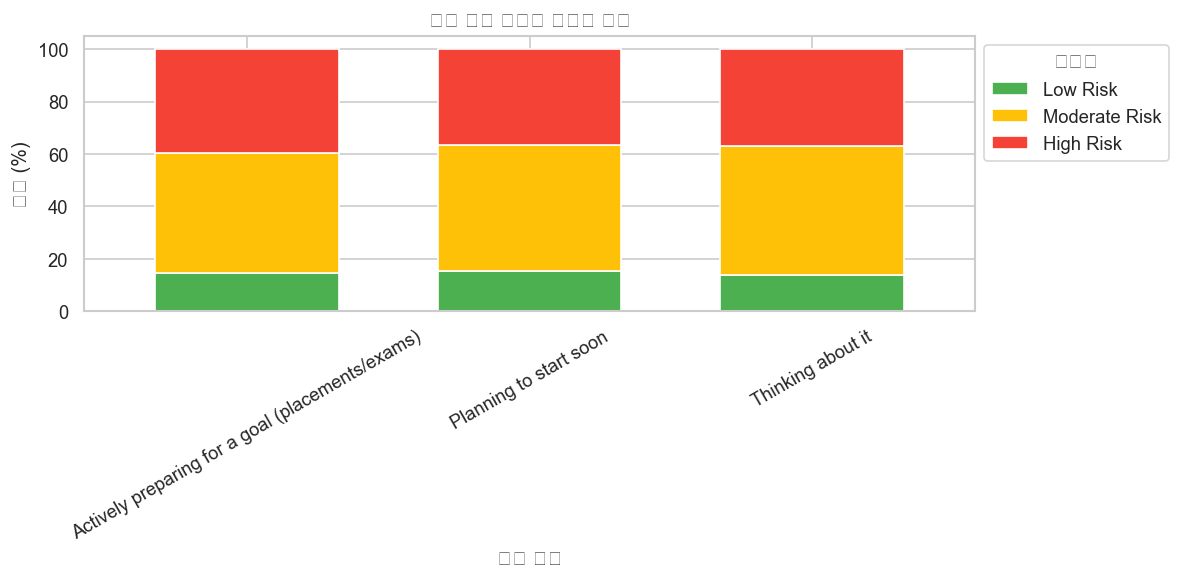

In [18]:
# 6-9. 준비 상태(preparation_status) × 위험도 비율 (100% 누적 막대)
prep_cross = pd.crosstab(df['preparation_status'], df['performance_risk_level'])
prep_cross = prep_cross.reindex(columns=risk_order, fill_value=0)
prep_pct = prep_cross.div(prep_cross.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
prep_pct.plot(kind='bar', stacked=True,
              color=[RISK_COLOR[r] for r in risk_order],
              ax=ax, edgecolor='white', width=0.65)
ax.set_title('시험 준비 상태별 위험도 비율', fontsize=12, fontweight='bold')
ax.set_xlabel('준비 상태')
ax.set_ylabel('비율 (%)')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='위험도', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

---
## 7. EDA 인사이트 정리

| # | 발견 사항 | 분석 근거 |
|---|-----------|----------|
| 1 | **출석률 ↑ → 고CGPA 집중** | 교차 히트맵(6-1): `Above 85%`에서 `8.5–9.4` 구간 비율 최고 |
| 2 | **공부 시간 ↑ → 고CGPA 비율 증가** | 누적 막대(6-2): `More than 5 hours` 그룹에서 고CGPA 분포 우편향 |
| 3 | **스트레스 ↑ · 에너지 ↓ → High Risk 경향** | 산점도(6-3): High Risk 클러스터가 고스트레스·저에너지 영역에 밀집 |
| 4 | **수면 7–8시간 그룹이 Low Risk 최다** | 카운트플롯(6-5): 과수면(8시간 초과)도 High Risk 비율 증가 |
| 5 | **일일 생산성 ↑ → 고CGPA 뚜렷** | 바이올린(6-6): 생산성은 CGPA 구간에 따라 단조 증가 |
| 6 | **스트레스와 CGPA는 비선형** | 바이올린(6-6): 고CGPA 구간에서도 스트레스 분포 넓음 (압박감 공존) |
| 7 | **일찍 준비할수록 Low Risk 비율 높음** | 누적 막대(6-9): `Already Started` 그룹이 Low Risk 최대 비율 |

### 모델링 방향

**피처 우선순위 (예상)**
1. `attendance_percentage` — CGPA 구간 분리에 가장 명확한 신호
2. `study_hours_daily` / `study_hours_num` — 공부량 대리 변수
3. `daily_productivity`, `energy_level` — 수치형, 직접 활용 가능
4. `stress_level`, `sleep_hours` — 위험도 분류에 중요
5. `preparation_status`, `revision_frequency` — 습관 변수

**전처리 계획**
- 범주형 순서형 변수(`study_hours_daily`, `sleep_hours`, `attendance_percentage` 등) → Ordinal Encoding
- 비순서 범주형(`gender`, `program_stream`, `main_distractor` 등) → One-Hot Encoding
- 수치형 스케일링: StandardScaler 또는 MinMaxScaler

**모델 계획**
- 회귀(CGPA 수치 예측): Random Forest Regressor, XGBoost Regressor
- 분류(위험도 예측): Random Forest Classifier, XGBoost Classifier
- 불균형 클래스 처리: SMOTE 또는 class_weight 조정